<div align="center">
  <a href="https://pageindex.ai/developer">
    <img src="https://github.com/user-attachments/assets/bae02956-6c4e-4a0b-adea-257b0be4aaa1" width="100%" alt="PageIndex — Vectorless, Reasoning-based RAG">
  </a>
  <p>
    <a href="https://pageindex.ai/developer">🌐 Website</a> &nbsp; · &nbsp;
    <a href="https://developer.pageindex.ai/">☁️ Cloud</a> &nbsp; · &nbsp;
    <a href="https://docs.pageindex.ai/">📖 Docs</a> &nbsp; · &nbsp;
    <a href="https://github.com/VectifyAI/PageIndex">⭐ GitHub</a> &nbsp; · &nbsp;
    <a href="https://pageindex.ai/contact">✉️ Contact</a>
  </p>
</div>

---

# PageIndex Citations & Source Highlighting

**Trace an answer back to the exact region on the page.**

A useful citation lets readers check the evidence behind an answer. This notebook demonstrates how to turn **PageIndex Cloud’s block-level citations** into highlighted source regions in the original document.

We ask a question about revenue in a financial report, parse the citations in the answer, and use each reference’s document name and block ID to locate its source. We then fetch the full-page image and highlight the cited region so readers can compare the answer with the original context.

1. **Ask with citations** — Stream an answer with references to its supporting document blocks.
2. **Parse the references** — Extract the document name, page number, and block ID.
3. **Locate the evidence** — Resolve a reference to its page and bounding box.
4. **Highlight the source** — Display the page with the cited region highlighted.

**Before you start:** Have your OpenAI API key ready. This demo uses an existing document on PageIndex Cloud with the supplied demo access key. Highlighting requires a document with block-level layout data and a full-page image available.


## 01 · Set up

Install the PageIndex SDK for querying and retrieving source references, and Pillow for drawing highlights on page images.


In [ ]:
!pip install -U pageindex pillow

### Configure your client

Set your API keys and choose your chat `MODEL`. The client uses PageIndex Cloud to access the document and its layout blocks, and your chosen model to answer the question.


In [ ]:
import os
from pageindex import PageIndexClient

os.environ["PAGEINDEX_API_KEY"]="pageindex_demo_readonly_key"
os.environ["OPENAI_API_KEY"] = "Your OpenAI API key here"

MODEL = "gpt-5.6-luna"  # gpt-5.6-sol / gpt-5.6-terra / gpt-5.6-luna


client = PageIndexClient(
    index="cloud",
    chat=MODEL,
)

## 02 · Ask a question with citations

Ask about revenue in the demo financial report. With `citations=True`, the model is instructed to attach source references to its answer. The stream shows the answer alongside retrieval tool calls.

A block-level reference looks like `<cite doc="report.pdf" page="12" block="p12_text_3"/>`. These attributes connect the answer to a document, a page, and a specific region on that page.


In [15]:
messages = [{"role": "user", "content": "What is the revenue in last year"}]

response = None
for event in client.chat(messages, doc_id="pi-cmu3rrhyb00280dnsyshkq578",
                         stream=True, citations=True, protocol="responses"):
    if event["type"] == "response.output_text.delta":
        print(event["delta"], end="", flush=True)
    elif event["type"] == "response.output_item.done":
        item = event["item"]
        if item.get("type") == "function_call":
            print(f"\n[Tool call] {item['name']}({item.get('arguments', '')})", flush=True)
    elif event["type"] in {"response.completed", "response.incomplete", "response.failed"}:
        response = event["response"]



[Tool call] get_document_structure({"doc_name":"NVIDIA-FY2026-10-K.pdf","folder_id":"cmu3rre91000r0cp4qb90h0fa","part":1,"wait_for_completion":false})

[Tool call] get_page_content({"doc_name":"NVIDIA-FY2026-10-K.pdf","folder_id":"cmu3rre91000r0cp4qb90h0fa","pages":"37-40","wait_for_completion":false})
NVIDIA’s revenue in the prior fiscal year, **fiscal 2025**, was **$130.497 billion**. <cite doc="NVIDIA-FY2026-10-K.pdf" page="37" block="p37_table_6"/>

## 03 · Parse the citation references

Extract `doc`, `page`, and `block` from the answer’s `<cite>` tags. The parser returns a list of references in source order, including repeats, and handles either quote style and any attribute order.

This example highlights individual blocks, so references without `doc` or `block` are skipped. A missing `page` is returned as `None`; the block lookup in the next step provides the page number.


In [16]:
from html.parser import HTMLParser


def parse_citations(text):
    """Extract doc/page/block references from complete <cite> tags, in source order."""
    class CitationParser(HTMLParser):
        def __init__(self):
            super().__init__()
            self.citations = []

        def handle_starttag(self, tag, attrs):
            if tag != "cite":
                return
            attrs = dict(attrs)
            if attrs.get("doc") and attrs.get("block"):
                self.citations.append({
                    "doc": attrs["doc"],
                    "page": attrs.get("page"),
                    "block": attrs["block"],
                })

    parser = CitationParser()
    parser.feed(text)
    parser.close()
    return parser.citations


# Read only the assistant's answer, excluding tool calls and tool outputs.
answer_text = "\n".join(
    part.get("text", "")
    for item in (response or {}).get("output", [])
    if item.get("type") == "message" and item.get("role") == "assistant"
    for part in item.get("content", [])
    if part.get("type") == "output_text"
)

citations = parse_citations(answer_text)
citations


[{'doc': 'NVIDIA-FY2026-10-K.pdf', 'page': '37', 'block': 'p37_table_6'}]

## 04 · Locate the source block

Select a reference with `citation_index` (`0` selects the first). Resolve its document name with `get_document_id()`, then call `get_block()` to retrieve the cited block’s page and bounding box.

The lookup also checks that the block’s page matches the citation when a page number is present. The next cell uses this bounding box to place the highlight on the full-page image.


In [18]:
# Select a citation from the parsed list (0 = the first citation).
citation_index = 0
if not citations:
    raise ValueError("No block-level citations found. Run the query and parser cells first.")

citation = citations[citation_index]
doc_id = client.get_document_id(citation["doc"])
block = client.get_block(doc_id, citation["block"])
page_number = int(block["page"])
if citation.get("page") and int(citation["page"]) != page_number:
    raise ValueError("The cited page does not match the block's page.")
bbox = block["bbox"]  # [x0, y0, x1, y1], normalized to 0–1000
print({"doc": citation["doc"], "page": page_number, "block": citation["block"], "bbox": bbox})


{'doc': 'NVIDIA-FY2026-10-K.pdf', 'page': 37, 'block': 'p37_table_6', 'bbox': [26, 378, 975, 512]}


## 05 · Highlight the cited region

Fetch the selected citation’s **full-page image** and draw a translucent yellow highlight with an orange outline over its bounding box. Keeping the whole page visible lets readers check the surrounding context as well as the cited passage.

Coordinates use `[x0, y0, x1, y1]` on a **0–1000 scale**, measured from the top-left. Convert them to pixels with `x / 1000 × image_width` and `y / 1000 × image_height`. The preview is resized to at most 1000 pixels wide after highlighting, preserving the page’s proportions.

This step retrieves the page through PageIndex Cloud and draws the highlight locally; it does not run another model query. Change `citation_index` above and rerun the lookup and highlighting cells to inspect another reference.


NVIDIA-FY2026-10-K.pdf · Page 37 · p37_table_6


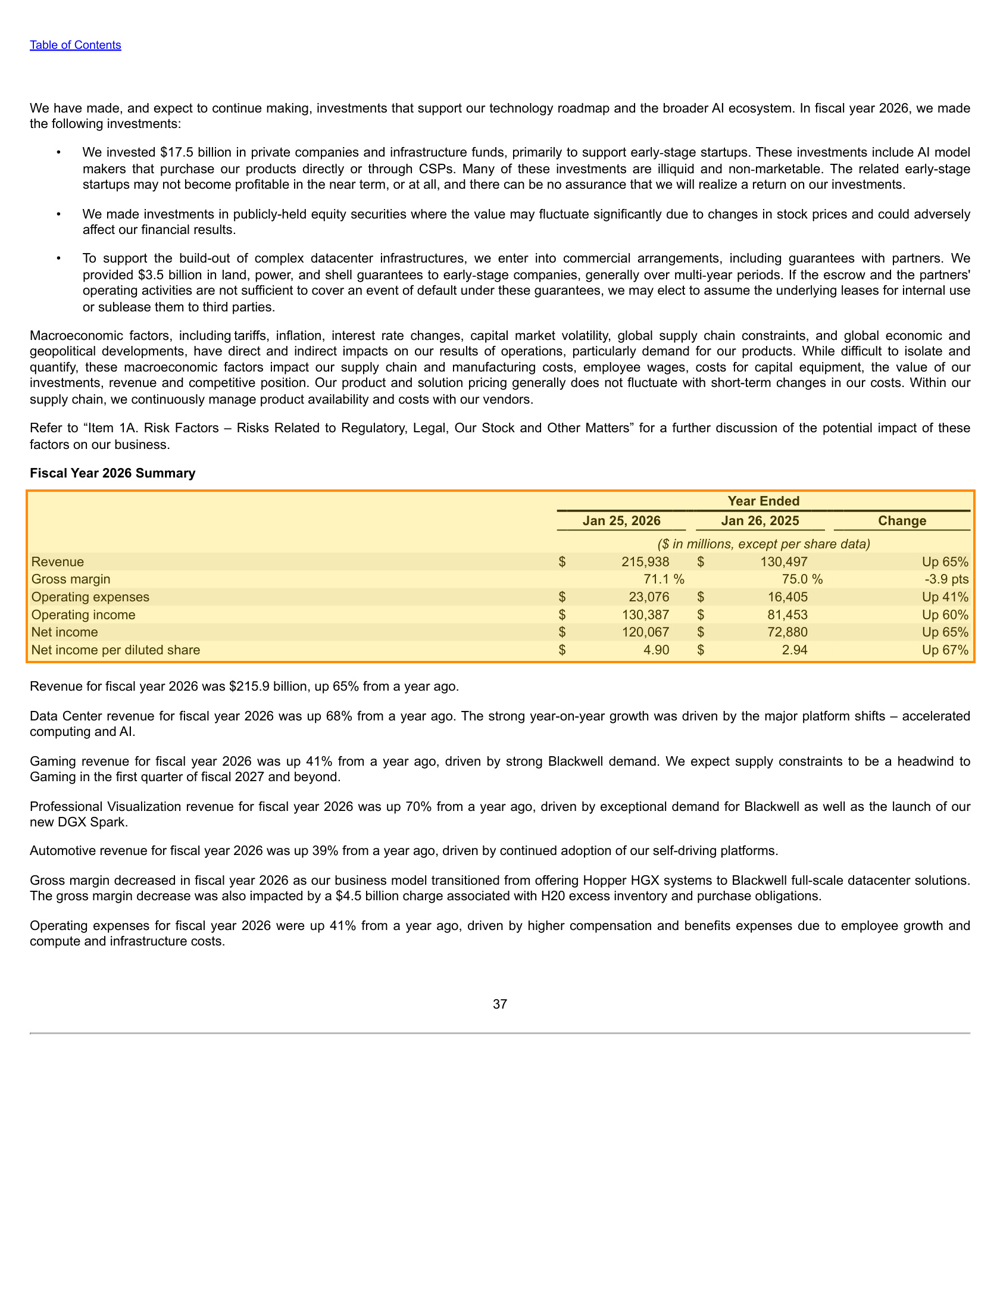

In [19]:
import base64
import json
from io import BytesIO
from PIL import Image as PILImage, ImageDraw
from IPython.display import display
from pageindex.mcp_bridge import McpBridge


def highlight_region(image, bbox, scale=1000):
    """Map a top-left-origin normalized bbox onto the full-page image."""
    x0, y0, x1, y1 = map(float, bbox)
    if scale <= 0 or not (0 <= x0 < x1 <= scale and 0 <= y0 < y1 <= scale):
        raise ValueError(f"Invalid bbox for scale {scale}: {bbox}")
    page = image.convert("RGBA")
    width, height = page.size
    rect = (x0 / scale * width, y0 / scale * height,
            x1 / scale * width, y1 / scale * height)
    overlay = PILImage.new("RGBA", page.size, (0, 0, 0, 0))
    ImageDraw.Draw(overlay).rectangle(
        rect, fill=(255, 210, 0, 65), outline=(255, 140, 0, 255),
        width=max(2, round(width / 400)),
    )
    return PILImage.alpha_composite(page, overlay).convert("RGB")


def get_full_page_image(client, doc_id, page_number):
    # Use the MCP bridge to retain raw image bytes; agent_tools() returns text.
    bridge = McpBridge(
        client.BASE_URL.rstrip("/") + "/mcp?tools=read",
        {"Authorization": f"Bearer {client.api_key}"},
    )
    doc = client.get_document(doc_id)
    folder = {"folder_id": doc.get("folderId") or "root"}
    content, is_error = bridge.call_tool("get_page_content", {
        "doc_name": doc["name"], "pages": str(page_number), **folder,
    })
    if is_error:
        raise RuntimeError("Could not retrieve the cited page's content.")

    image_path = None
    for part in content:
        if part.get("type") != "text":
            continue
        try:
            payload = json.loads(part["text"])
        except (ValueError, KeyError):
            continue
        if not isinstance(payload, dict):
            continue
        for page in payload.get("page_images", []):
            if str(page.get("page")) == str(page_number):
                image_path = page.get("image_path")
                break
    if not image_path:
        raise ValueError("No full-page image returned for this page; cannot place the bbox accurately.")

    # Use the exact full-page path returned by the server, not an embedded crop.
    content, is_error = bridge.call_tool("get_document_image", {
        "image_path": image_path, **folder,
    })
    if is_error:
        raise RuntimeError("Could not retrieve the cited page's image.")
    for part in content:
        if part.get("type") == "image":
            with PILImage.open(BytesIO(base64.b64decode(part["data"]))) as image:
                return image.convert("RGB")
    raise ValueError("The image tool returned no image data.")


page_image = get_full_page_image(client, doc_id, page_number)
highlighted_page = highlight_region(page_image, bbox, scale=1000)
# Resize only after highlighting, keeping the page's aspect ratio.
preview = highlighted_page.copy()
preview.thumbnail((1000, 10000))
print(f"{citation['doc']} · Page {page_number} · {citation['block']}")
display(preview)


## 06 · Review usage & estimated cost (optional)

Inspect the token usage for the answer and estimate its model cost using the rate table below. Parsing citations and drawing highlights do not require additional model calls. This estimate does not include PageIndex Cloud charges.


In [20]:
import json

# Standard USD per 1M tokens: (input, cached input, output).
# Checked 2026-09-17: https://developers.openai.com/api/docs/models/{model}
PRICES = {
    "gpt-5.6-sol": (4.0, 0.4, 20.0),
    "gpt-5.6-terra": (2.0, 0.2, 12.0),
    "gpt-5.6-luna": (0.2, 0.02, 1.2),
}
input_rate, cached_rate, output_rate = PRICES[MODEL]

usage = response.get("usage") if response else None
print("\n\nUsage:", json.dumps(usage, ensure_ascii=False, indent=2))
if response and response.get("status") != "completed":
    print("Response did not complete:", response.get("error") or response.get("incomplete_details"))

if usage:
    details = usage.get("input_tokens_details") or {}
    cached = details.get("cached_tokens", 0) or 0
    written = details.get("cache_write_tokens", 0) or 0
    regular = usage["input_tokens"] - cached - written
    cost = (regular * input_rate + cached * cached_rate + written * input_rate * 1.25
            + usage["output_tokens"] * output_rate) / 1_000_000
    print(f"Estimated model cost at base rates: ${cost:.6f} USD")
    if usage["input_tokens"] > 272_000:
        print("Usage is aggregated across model calls; the estimate excludes possible long-context surcharges.")
else:
    print("No usage returned; unable to estimate cost.")



Usage: {
  "input_tokens": 40203,
  "input_tokens_details": {
    "cached_tokens": 23318,
    "cache_write_tokens": 16876
  },
  "output_tokens": 244,
  "output_tokens_details": {
    "reasoning_tokens": 63
  },
  "total_tokens": 40447
}
Estimated model cost at base rates: $0.004980 USD


---

<div align="center">
  <br>
  <p>
    <a href="https://docs.pageindex.ai/"><b>Upload your documents</b></a>
    &nbsp;&nbsp; · &nbsp;&nbsp;
    <a href="https://docs.pageindex.ai/sdk/agents"><b>Integrate with your agent</b></a>
    &nbsp;&nbsp; · &nbsp;&nbsp;
    <a href="https://github.com/VectifyAI/PageIndex"><b>Star PageIndex on GitHub</b></a>
  </p>
  <br>
  <a href="https://pageindex.ai">
    <img src="https://github.com/user-attachments/assets/e1c677f2-b590-4ffc-859d-e8cc7d794bdf" width="144" height="40" alt="PageIndex">
  </a>
</div>
